# One-loop Z2SSM $\leftrightarrow$ SMEFT Matching

In [119]:
import numpy as np
import sys
import os
import subprocess
import matplotlib as mpl
from copy import deepcopy
from matplotlib import pyplot as plt
from IPython.display import HTML
from matplotlib.backends.backend_pdf import PdfPages


mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["savefig.dpi"] = 600


sys.path.append(os.path.abspath("/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/"))

# Enable autoreload extension
%load_ext autoreload

# Reload only the utils package before running a cell
%autoreload 1
%aimport fit_utils
%aimport fit_utils.utils
%aimport fit_utils.pullplots
%aimport fit_utils.parser
%aimport fit_utils.EFT_matching

import fit_utils.utils as utils
import fit_utils.pullplots as pullplots
import fit_utils.parser as parser
import fit_utils.EFT_matching as EFT_matching

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## $\Lambda_{\text{NP}} = \mu_{S}$

In [145]:
import pickle
vev = 246.
Mh = 125.

BP_input_dir = "/cephfs/user/mrebuzzi/phd/HiggsTools/future_projections/scan_output/Z2SSM_scan_output"
# BP_input_dir = "."
BP_dicts_filename = f"{BP_input_dir}/Benchmark_Points_outliers_dicts.pkl"
# BP_dicts_filename = f"{BP_input_dir}/Z2SSM_Benchmark_Points_outliers_dicts.pkl"

with open(BP_dicts_filename, 'rb') as f:
    BPs = pickle.load(f)
    bp_kappas = BPs["kappas"]
    # bp_EWPOs = BPs["EWPOs"]
    bp_model_pars = BPs["model_pars"]
    bp_indices = BPs["indices"]

print("BP kappas:", bp_kappas)
# print("BP EWPOs:", bp_EWPOs)
print("BP model parameters:", bp_model_pars)
print("BP indices:", bp_indices)

mS = np.array([bp["mS"] for bp in bp_model_pars]); print("\nmS:", mS)
muS = np.array([bp["muS"] for bp in bp_model_pars]); print("\nmuS:", muS)
lamS = np.array([bp["lamS"] for bp in bp_model_pars]); print("\nlamS:", lamS)
lamSH = np.array([bp["lamSH"] for bp in bp_model_pars]); print("\nlamSH:", lamSH)
bp_lambdas = np.array([bp["lam"] for bp in bp_kappas]); print("\nBP lambdas (2L):", bp_lambdas)
bp_lambdas_1L = np.array([bp["lam1L"] for bp in bp_kappas]); print("\nBP lambdas (1L):", bp_lambdas_1L)

# Testing the relation between mS, muS, lamSH
mS_test = np.sqrt(muS**2 + 0.5*lamSH*vev**2); print("\nmS test (from muS, lamSH):", mS_test)
mS_diff = mS - mS_test; print("\nmS - mS test:", mS_diff)

# Initialize the Z2SSM matching class
Z2SSM = EFT_matching.Z2SSM(muS=muS, lamS=lamS, lamSH=lamSH)
# lamNP=1000 #GeV

# Getting the matched Wilson coefficients at the NP scale
lamNP_tex = r'\mu_{S}'; lamNP_str = 'muS'
lamNP_match = muS
matched_WCs = Z2SSM.get_coefficients(lamNP_match=lamNP_match)
print("\nMatched Wilson coefficients at lamNP = muS:")
for wc_name, wc_values in matched_WCs.items():
    print(f"{wc_name}: {wc_values}")

matched_kappa_lambdas = Z2SSM.get_kappa_lambda_SMEFT_match(lamNP_match=lamNP_match)
print(f"\nMatched SMEFT kappa_lambda at lamNP = {lamNP_tex}:\n", matched_kappa_lambdas)
print("\nModel kappa_lambda predictions: ", bp_lambdas)


# sort_indices = np.arange(14)
# sort_indices = [3, 5, 7, 9, 11]
# sort_indices = [0, 1, 2, 4, 6, 8, 10, 12, 13, ]

# Sorting arrays according to their 2L kala Z2SSM prediction
sort_indices = np.argsort(bp_lambdas)
# sort_indices = np.array([0, 1, 2, 4])
print("\nSorting indices:", sort_indices)
main_BP_indices = [0, 1, 2, 4]
main_BP_new_indices = np.array([sort_indices.tolist().index(i) for i in main_BP_indices])
print("Main BP new indices:", main_BP_new_indices)

bp_lambdas = bp_lambdas[sort_indices]
bp_lambdas_1L = bp_lambdas_1L[sort_indices]
matched_kappa_lambdas = matched_kappa_lambdas[sort_indices]
mS = mS[sort_indices]
muS = muS[sort_indices]
lamS = lamS[sort_indices]
lamSH = lamSH[sort_indices]
CH    = deepcopy(matched_WCs["CH"])    [sort_indices]
CHbox = deepcopy(matched_WCs["CHbox"]) [sort_indices]

BP kappas: [{'lam': 1.0643594459030925, 'kappaSingleHiggs': 0.997795157109014, 'lam1L': 1.0163047292403735, 'uu': 0.997795157109014, 'dd': 0.997795157109014, 'ss': 0.997795157109014, 'cc': 0.997795157109014, 'bb': 0.997795157109014, 'tt': 0.997795157109014, 'ee': 0.997795157109014, 'mumu': 0.997795157109014, 'tautau': 0.997795157109014, 'ZZ': 0.997795157109014, 'WW': 0.997795157109014, 'gamgam': 0.997795157109014, 'Zgam': 0.997795157109014, 'gg': 0.997795157109014, 'ZZ_0': 0.9980563471636651, 'ZZ_0_with_WFR': 0.9979539099793131, 'ZZ_0_no_BSM': 1.0002630443516598, 'ZZ_0_with_WFR_no_BSM': 1.0001608331788296, 'ZZ_240': 0.9983849781927755, 'ZZ_240_with_WFR': 0.9982825747303763, 'ZZ_240_no_BSM': 1.0005909506201627, 'ZZ_240_with_WFR_no_BSM': 1.000488772946644, 'ZZ_240_use_HEPfit_C1_values': 0.9983408359865786, 'ZZ_240_with_WFR_HEPfit_C1_values': 0.9982384279958877, 'ZZ_365': 0.9980039274452023, 'ZZ_365_with_WFR': 0.9979014848798298, 'ZZ_365_no_BSM': 1.0002107402832767, 'ZZ_365_with_WFR_no_BS

### $\kappa_\lambda$

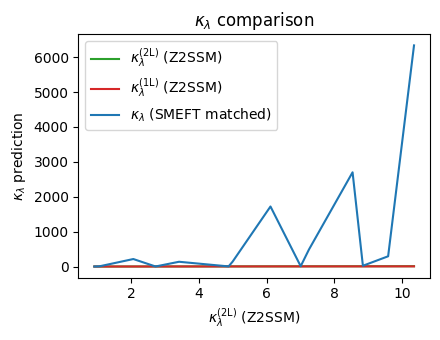

In [146]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, bp_lambdas, color='tab:green', label=r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.plot(bp_lambdas, bp_lambdas_1L, color='tab:red', label=r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (Z2SSM)')
ax.plot(bp_lambdas, matched_kappa_lambdas, color='tab:blue', label=r'$\kappa_{\lambda}$ (SMEFT matched)')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'$\kappa_{\lambda}$ prediction')
ax.set_title(r'$\kappa_{\lambda}$ comparison')
ax.legend()
plt.tight_layout()

plot_dir = "./comparison_plots/matching_comparison"
subprocess.run(["mkdir", "-p", plot_dir])
plt.savefig(f"{plot_dir}/kappa_lambda_matching_comparison_lambda_matching_{lamNP_str}.pdf")

### $\kappa_\lambda$ (Zoomed-in version)

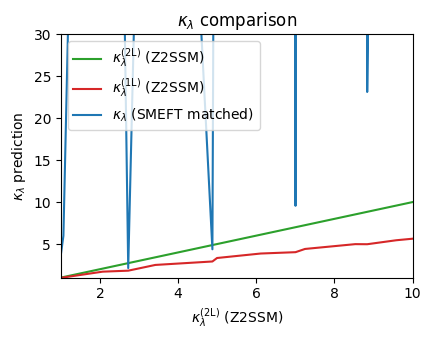

In [122]:
ax.set_xlim(1,10)
ax.set_ylim(1,30)
fig.savefig(f"{plot_dir}/kappa_lambda_matching_comparison_lambda_matching_{lamNP_str}_zoom.pdf")
fig

### Wilson coefficients

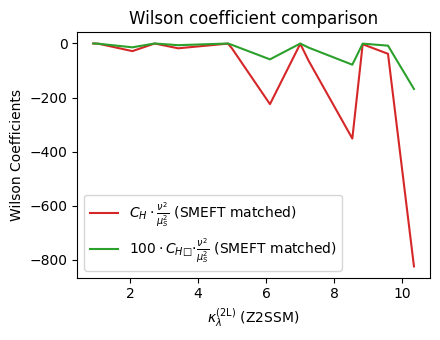

In [123]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, CH*vev**2, color='tab:red', label=r'$C_{H}\cdot \frac{\nu^2}{' + lamNP_tex + r'^{2}}$ (SMEFT matched)')
ax.plot(bp_lambdas, 10*CHbox*vev**2, color='tab:green', label='$100\cdot C_{H\u25A1}$'+r'$\cdot \frac{\nu^2}{' + lamNP_tex + r'^{2}}$ (SMEFT matched)')
# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'Wilson Coefficients')
ax.set_title(r'Wilson coefficient comparison')

ax.legend()
plt.tight_layout()

plot_dir = "./comparison_plots/matching_comparison"
subprocess.run(["mkdir", "-p", plot_dir])
plt.savefig(f"{plot_dir}/WCs_matching_comparison_lambda_matching_{lamNP_str}.pdf")

### Model parameters

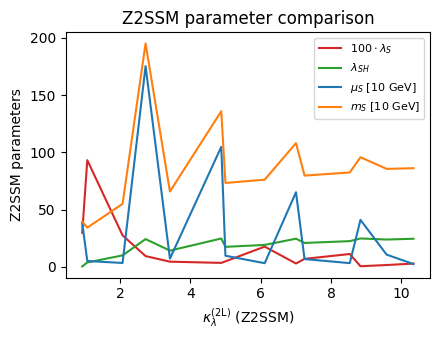

In [124]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, 100*lamS, color='tab:red', label=r'$100\cdot\lambda_{S}$')
ax.plot(bp_lambdas, lamSH, color='tab:green', label=r'$\lambda_{SH}$')
ax.plot(bp_lambdas, muS/10., color='tab:blue', label=r'$\mu_{S}$ [10 GeV]')
ax.plot(bp_lambdas, mS/10., color='tab:orange', label=r'$m_{S}$ [10 GeV]')

# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'Z2SSM parameters')
ax.set_title(r'Z2SSM parameter comparison')
ax.legend(fontsize=8)
plt.tight_layout()

plt.savefig(f"{plot_dir}/Z2SSM_parameters_matching_comparison.pdf")

# Comparison with fitted values

In [125]:
model = "Z2SSM"
working_dir = "."

all_scenarios = [f"{model}_FCCee240_FCCee365"]

specs = [
    # "fits_long",
    # "fits_full",
    # "fits_realistic_HL_LHC_WFR_kala2_input_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_no_C_HG_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_realistic_HL_LHC_long",
    # "fits_realistic_HL_LHC_all_EW_mods_long",
    # "fits_realistic_HL_LHC_no_1L_BSM_sqrt_s_long",
    # "fits_realistic_HL_LHC_no_1L_BSM_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_sqrt_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_no_cross_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_all_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_no_cross_no_C_HG_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_no_cross_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_external_leg_small_priors_long",
    # "fits_realistic_HL_LHC_small_priors_long",
    # "fits_realistic_HL_LHC_no_quad_long",
    # "fits_realistic_HL_LHC_noLoopH3d6Quad_long",
    # "fits_realistic_HL_LHC_noLoopH3d6Quad_no_quad_long",
    # "fits_realistic_HL_LHC_LoopHd6noWFR_no_quad_long",
    # "fits_realistic_HL_LHC_LoopHd6noWFR_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_all_EW_mods_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_WFR_kala2_input_all_all_EW_mods_no_HLLHC_Higgs_small_priors_long",
]

spec_labels_dict = {
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long" : "Original",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long" : "Using HEPfit C1 values",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long" : "Using HEPfit C1 values \n(including decay rates)",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long" : "Fit results",
    # "fits_realistic_HL_LHC_smeft_formula_all_small_priors_long" : "Using HEPfit formulas",
}
spec_labels = list(spec_labels_dict.values())

model_specs = {f"{model}_FCCee240_FCCee365" : specs,}
scenario_titles_dict = {f"{model}_FCCee240_FCCee365" : rf"FCC-ee$_{{240}}$ + FCC-ee$_{{365}}$",}
scenario_titles = list(scenario_titles_dict.values())

model_specs_labels = {f"{model}_FCCee240_FCCee365" : spec_labels,}


results_dirs = specs
results_dir_compare = "matching_comparison"

BPs = []; BPOs = []; BPBs = []
BPBnews = ["BPBnew_0", "BPBnew_1", "BPBnew_2", "BPBnew_4", ]

BPs = BPs + BPOs + BPBs + BPBnews

BP_names = [f"BP {i}" for i in range(len(BPs))]

BP_lambdas_all = [
    1.0643594459030925, # BPB_0
    2.068362744578383,  # BPB_1
    3.41660475844658,   # BPB_2
    0.9197317035823376, # BPB_3
    4.996504503173265,  # BPB_4
    2.723103795696014,  # BPB_5
    6.114019817191308,  # BPB_6
    4.878015572616551,  # BPB_7
    7.24831645311373,   # BPB_8
    7.005268951781772,  # BPB_9
    8.535635929341407,  # BPB_10
    8.84021000223677,   # BPB_11
    9.584476423981522,  # BPB_12
    10.34814810189343,  # BPB_13
]

BP_lambdas_0124 = [
    1.0643594459030925, # BPB_0
    2.068362744578383,  # BPB_1
    3.41660475844658,   # BPB_2
    4.996504503173265,  # BPB_4
]

plot_titles = { 
    scenario : { 
        # spec : f"{scenario_titles_dict[scenario]} scenario \n{spec_labels_dict[spec]}" 
        spec : f"{spec_labels_dict[spec]}" 
        for spec in model_specs[scenario] 
    } 
    for scenario in all_scenarios
}

In [126]:
scenarios = model_specs.keys()
files = {}
for BP in BPs:
    files[BP] = {}
    for scenario in scenarios:
        files[BP][scenario] = {}
        for model_spec in model_specs[scenario]:
            files[BP][scenario][model_spec] = f"{working_dir}/{BP}/{scenario}/results_{model_spec}/Observables/Statistics.txt"

correlation_matrices = parser.read_fit_results_dim6Ops_correlations(
    BPs=BPs,
    model_specs=model_specs,
    files=files,
)
# print(correlation_matrices)

Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix


Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix


Reading file: ./BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix


Reading file: ./BPBnew_4/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix




{'CH': array([-1.12142284e-05, -4.66822486e-04, -2.94818676e-04, -1.02928250e-10,
       -2.99944124e-04, -2.43906464e-06, -3.70604026e-03, -7.25225279e-06,
       -1.04650082e-03, -1.83998687e-05, -5.80766424e-03, -4.75770104e-05,
       -6.30723104e-04, -1.36201679e-02]), 'CHbox': array([-1.48227115e-06, -2.34350670e-05, -1.04350653e-05, -1.68188069e-10,
       -8.60325102e-06, -5.03566168e-08, -9.70307460e-05, -1.46724399e-07,
       -2.51163527e-05, -3.74824240e-07, -1.29603830e-04, -9.61681056e-07,
       -1.32463080e-05, -2.78113426e-04]), 'CW': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHG': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHWB': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHWHB_gaga': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHWHB_gagaorth': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHW': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

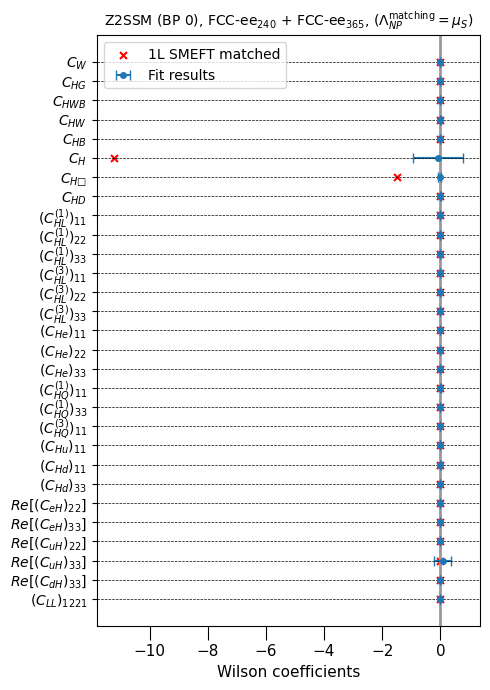

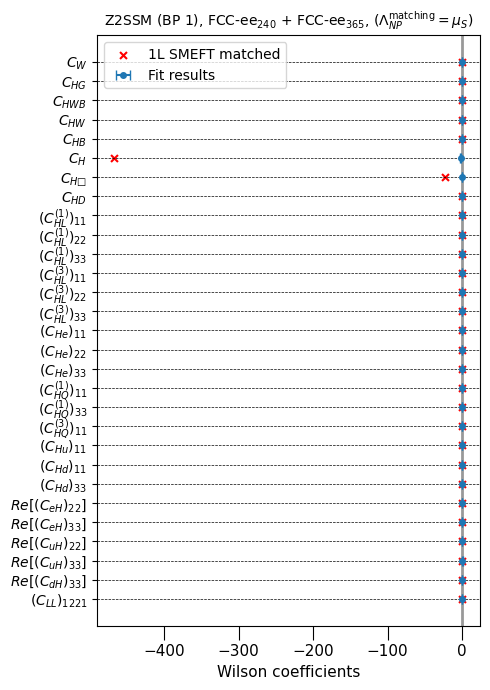

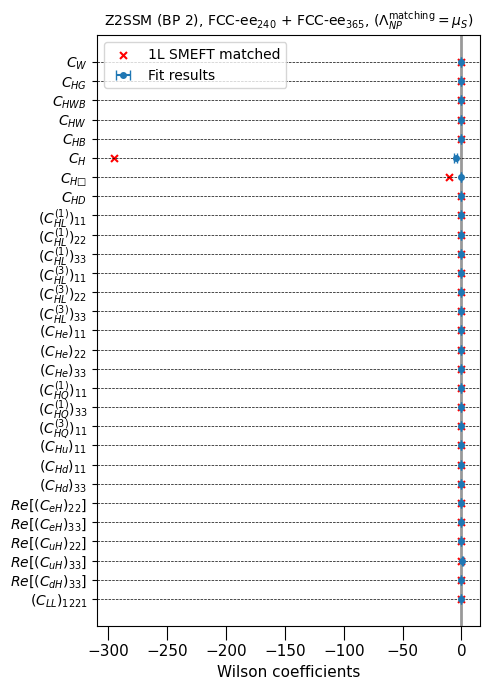

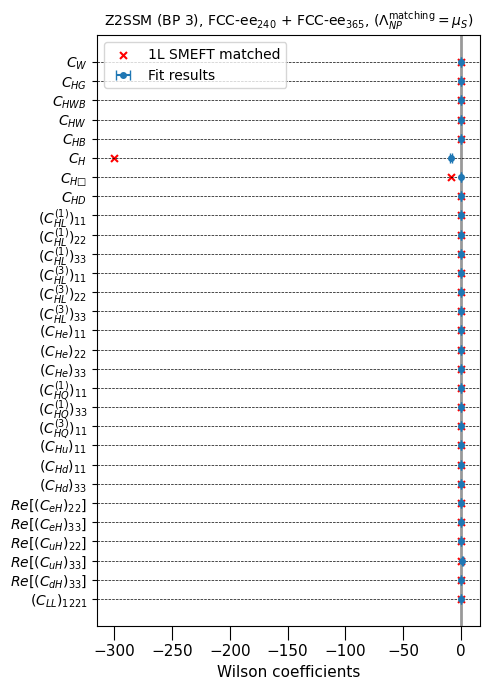

In [127]:
plot_titles = { 
    BP : {
        scenario : rf"{model} ({BP_name}), {scenario_title}, "+r'($\Lambda_{NP}^\mathrm{matching}=$'rf'${lamNP_tex}$)'
        for scenario, scenario_title in zip(all_scenarios, scenario_titles)
    } 
    for BP, BP_name in zip(BPs, BP_names)
}

print(matched_WCs)
lamNP_hepfit = 1000 #GeV
plotted_BPs = [0, 1, 2, 4]  # Indices of BPs to be plotted

matched_WCs_hepfit_compare = {wc : matched_WCs[wc][plotted_BPs] * (lamNP_hepfit)**2 for wc in matched_WCs.keys()}
print(matched_WCs_hepfit_compare)

pullplots.generate_pull_plots_pars(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles,
    model=model,
    colors=None,
    show_plots=True,
    nvar_per_plot=50,
    figsize=(5, 7),
    normalize_pulls=False,
    true_values={
        'values': matched_WCs_hepfit_compare, 
        'label': '1L SMEFT matched', 
        'style': {'s': 25, 'marker': 'x', 'color': 'red'},
        'subtract_true_values': False
    },
    file_suffix=f"_absolute_WCs_lambda_matching_{lamNP_str}",
)


Finding configuration files for the observables

Setting configuration files for scenario: Z2SSM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Full fit flag: use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Files considered:
- Globalfits/AllOps/d6Ops_corr.conf

Reading configuration files for observables
Reading configuration file ./BPBnew_0/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BPBnew_1/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BPBnew_2/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BPBnew_4/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



{'BPBnew_0': {'Z2SSM_FCCee240_FCCee365': {'fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all

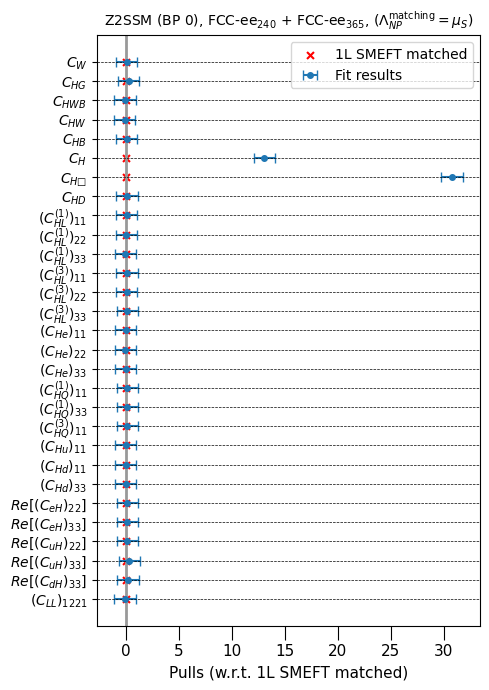

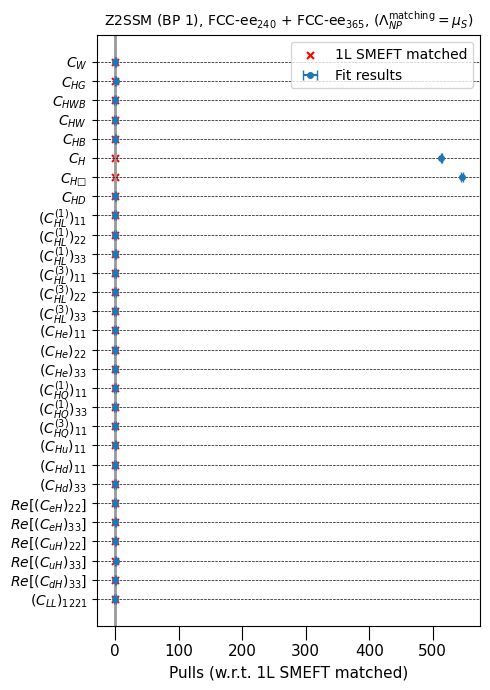

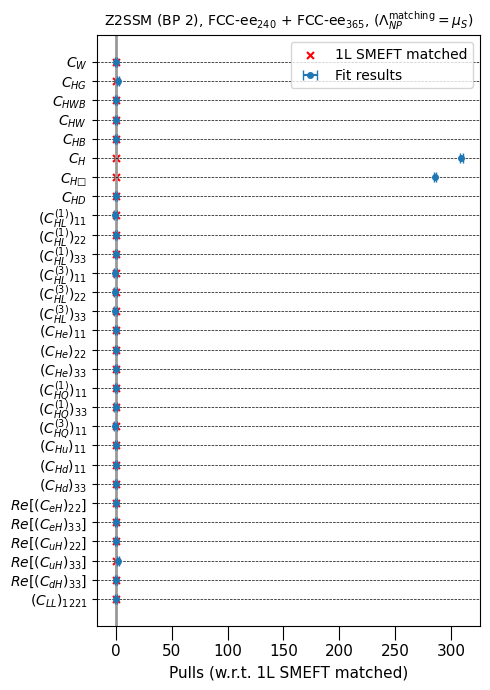

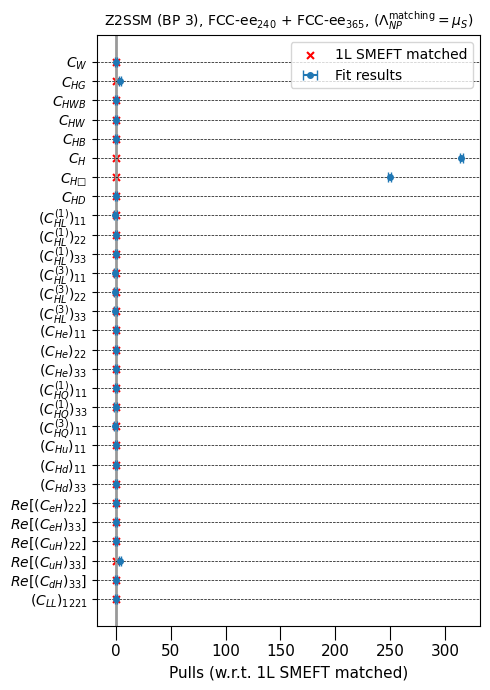

In [128]:

pullplots.generate_pull_plots_pars(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles,
    model=model,
    colors=None,
    show_plots=True,
    nvar_per_plot=50,
    figsize=(5, 7),
    normalize_pulls=True,
    true_values={
        'values': matched_WCs_hepfit_compare, 
        'label': '1L SMEFT matched', 
        'style': {'s': 25, 'marker': 'x', 'color': 'red'},
        'subtract_true_values': True
    },
    file_suffix=f"_WC_pulls_wrt_matched_absolute_WCs_lambda_matching_{lamNP_str}",
)

In [129]:
CH    = matched_WCs["CH"]    [plotted_BPs]
CHbox = matched_WCs["CHbox"] [plotted_BPs]


Reading fit results
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_4/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt


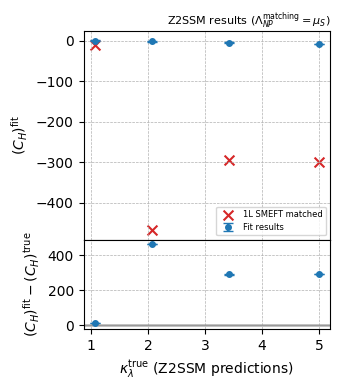


Reading fit results
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_4/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt


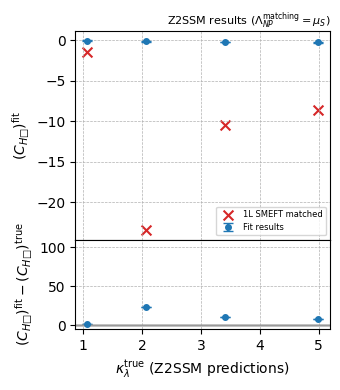

In [130]:

colors = ["tab:blue",]

utils.generate_obs_comparison_plot(
    observable='CH_corr',
    observable_label=r'(C_{H})',
    observable_text='CH',
    true_obs_values=CH*lamNP_hepfit**2,
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dir_compare,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
    model=model,
    plot_labels=spec_labels,
    plot_titles=None,
    group_model_specs=True,
    colors=colors,
    plot_true_obs={"color": "tab:red", "s": 50, "label": "1L SMEFT matched"},
    # plot_true_obs=None,
    show_plots=True,
    # x_lim = (0.5, 5.0),
    # y_lim_ax1=(0.2, 2.2),
    # y_lim_ax2=(-0.7, 0.7),
    leg_fontsize=6,
    spec_distance=0.2,
    # # upper_right_text=r"IDM inputs: strictly 1L BSM contributions",
    # upper_right_text=r"IDM inputs: 1L BSM + $\kappa_\lambda$-dependent diagrams",
    upper_right_text=rf"{model} results "+r'($\Lambda_{{NP}}^{{\mathrm{{matching}}}}=$'rf'${lamNP_tex}$)',
    file_suffix=f"_lambda_matching_{lamNP_str}",
)


utils.generate_obs_comparison_plot(
    observable='CHbox_corr',
    observable_label='(C_{H\u25A1})',
    observable_text='CHbox',
    true_obs_values=CHbox*lamNP_hepfit**2,
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dir_compare,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
    model=model,
    plot_labels=spec_labels,
    plot_titles=None,
    group_model_specs=True,
    colors=colors,
    plot_true_obs={"color": "tab:red", "s": 50, "label": "1L SMEFT matched"},
    # plot_true_obs=None,
    show_plots=True,
    # x_lim = (0.5, 5.0),
    # y_lim_ax1=(0.2, 2.2),
    y_lim_ax2=(-5, 110),
    leg_fontsize=6,
    spec_distance=0.2,
    # # upper_right_text=r"IDM inputs: strictly 1L BSM contributions",
    # upper_right_text=r"IDM inputs: 1L BSM + $\kappa_\lambda$-dependent diagrams",
    upper_right_text=rf"{model} results "+r'($\Lambda_{{NP}}^{{\mathrm{{matching}}}}=$'rf'${lamNP_tex}$)',
    file_suffix=f"_lambda_matching_{lamNP_str}",
)

## $\Lambda_{\text{NP}} = m_{S}$

In [131]:
mS = np.array([bp["mS"] for bp in bp_model_pars])

# Getting the matched Wilson coefficients at the NP scale
lamNP_tex = r'm_{S}'; lamNP_str = 'mS'
lamNP_match = mS

matched_WCs = Z2SSM.get_coefficients(lamNP_match=lamNP_match)
print(f"\nMatched Wilson coefficients at lamNP = {lamNP_str}:")
for wc_name, wc_values in matched_WCs.items():
    print(f"{wc_name}: {wc_values}")

matched_kappa_lambdas = Z2SSM.get_kappa_lambda_SMEFT_match(lamNP_match=lamNP_match)
print(f"\nMatched SMEFT kappa_lambda at lamNP = {lamNP_str}:\n", matched_kappa_lambdas)
print("\nModel kappa_lambda predictions: ", bp_lambdas)

mS = mS[sort_indices]
matched_kappa_lambdas = matched_kappa_lambdas[sort_indices]
CH    = deepcopy(matched_WCs["CH"])    [sort_indices]
CHbox = deepcopy(matched_WCs["CHbox"]) [sort_indices]


Matched Wilson coefficients at lamNP = mS:
CH: [-2.44131250e-07 -1.72370676e-06 -3.43970870e-06 -9.68252204e-11
 -5.20772166e-06 -1.96945499e-06 -6.34973507e-06 -4.31470864e-06
 -7.51510104e-06 -6.68788368e-06 -8.74202265e-06 -8.71650342e-06
 -9.73268697e-06 -1.04492835e-05]
CHbox: [-3.22687122e-08 -8.65322142e-08 -1.21748003e-07 -1.58215523e-10
 -1.49372277e-07 -4.06611158e-08 -1.66247393e-07 -8.72932936e-08
 -1.80364816e-07 -1.36239065e-07 -1.95086970e-07 -1.76187956e-07
 -2.04403753e-07 -2.13366389e-07]
CW: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHG: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHWB: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHWHB_gaga: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHWHB_gagaorth: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHW: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHB: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHD: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHL1_11: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHL1_22: [0. 0. 0. 0. 0.

### $\kappa_\lambda$

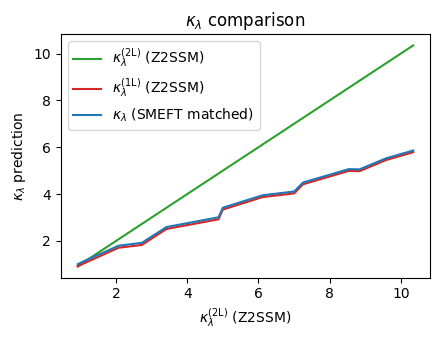

In [132]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, bp_lambdas, color='tab:green', label=r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.plot(bp_lambdas, bp_lambdas_1L, color='tab:red', label=r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (Z2SSM)')
ax.plot(bp_lambdas, matched_kappa_lambdas, color='tab:blue', label=r'$\kappa_{\lambda}$ (SMEFT matched)')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'$\kappa_{\lambda}$ prediction')
ax.set_title(r'$\kappa_{\lambda}$ comparison')
ax.legend()
plt.tight_layout()

plot_dir = "./comparison_plots/matching_comparison"
subprocess.run(["mkdir", "-p", plot_dir])
plt.savefig(f"{plot_dir}/kappa_lambda_matching_comparison_lambda_matching_{lamNP_str}.pdf")

### $\kappa_\lambda$ (Zoomed-in version)

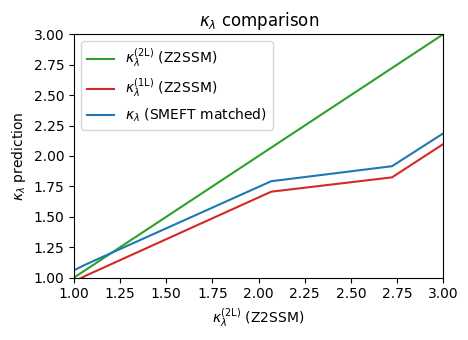

In [133]:
ax.set_xlim(1,3)
ax.set_ylim(1,3)
fig.savefig(f"{plot_dir}/kappa_lambda_matching_comparison_lambda_matching_{lamNP_str}_zoom.pdf")
fig

### Wilson coefficients

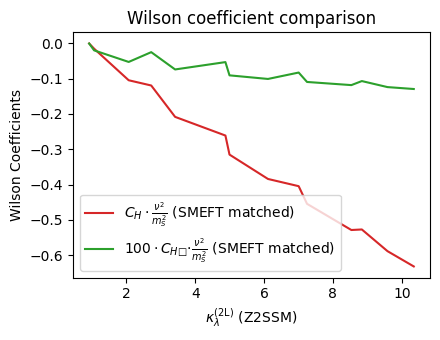

In [134]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, CH*vev**2, color='tab:red', label=r'$C_{H}\cdot \frac{\nu^2}{' + lamNP_tex + r'^{2}}$ (SMEFT matched)')
ax.plot(bp_lambdas, 10*CHbox*vev**2, color='tab:green', label='$100\cdot C_{H\u25A1}$'+r'$\cdot \frac{\nu^2}{' + lamNP_tex + r'^{2}}$ (SMEFT matched)')
# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'Wilson Coefficients')
ax.set_title(r'Wilson coefficient comparison')

ax.legend()
plt.tight_layout()

plot_dir = "./comparison_plots/matching_comparison"
subprocess.run(["mkdir", "-p", plot_dir])
plt.savefig(f"{plot_dir}/WCs_matching_comparison_lambda_matching_{lamNP_str}.pdf")

# Comparison with fitted values

In [135]:
scenarios = model_specs.keys()
files = {}
for BP in BPs:
    files[BP] = {}
    for scenario in scenarios:
        files[BP][scenario] = {}
        for model_spec in model_specs[scenario]:
            files[BP][scenario][model_spec] = f"{working_dir}/{BP}/{scenario}/results_{model_spec}/Observables/Statistics.txt"

correlation_matrices = parser.read_fit_results_dim6Ops_correlations(
    BPs=BPs,
    model_specs=model_specs,
    files=files,
)
# print(correlation_matrices)

Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix


Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix


Reading file: ./BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix


Reading file: ./BPBnew_4/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix




{'CH': array([-2.44131250e-07, -1.72370676e-06, -3.43970870e-06, -9.68252204e-11,
       -5.20772166e-06, -1.96945499e-06, -6.34973507e-06, -4.31470864e-06,
       -7.51510104e-06, -6.68788368e-06, -8.74202265e-06, -8.71650342e-06,
       -9.73268697e-06, -1.04492835e-05]), 'CHbox': array([-3.22687122e-08, -8.65322142e-08, -1.21748003e-07, -1.58215523e-10,
       -1.49372277e-07, -4.06611158e-08, -1.66247393e-07, -8.72932936e-08,
       -1.80364816e-07, -1.36239065e-07, -1.95086970e-07, -1.76187956e-07,
       -2.04403753e-07, -2.13366389e-07]), 'CW': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHG': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHWB': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHWHB_gaga': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHWHB_gagaorth': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHW': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

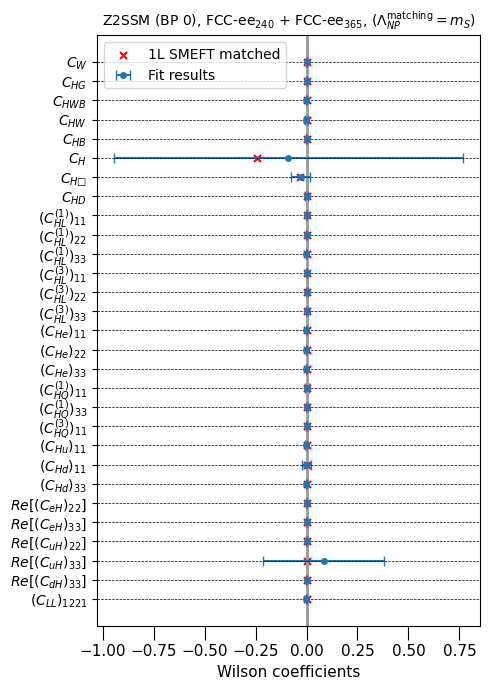

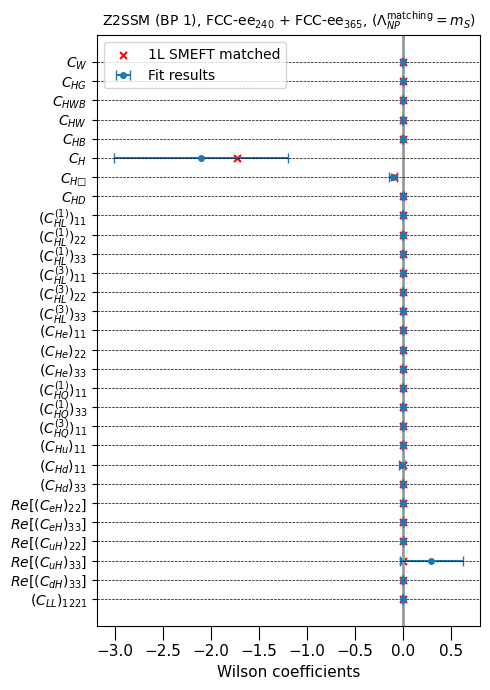

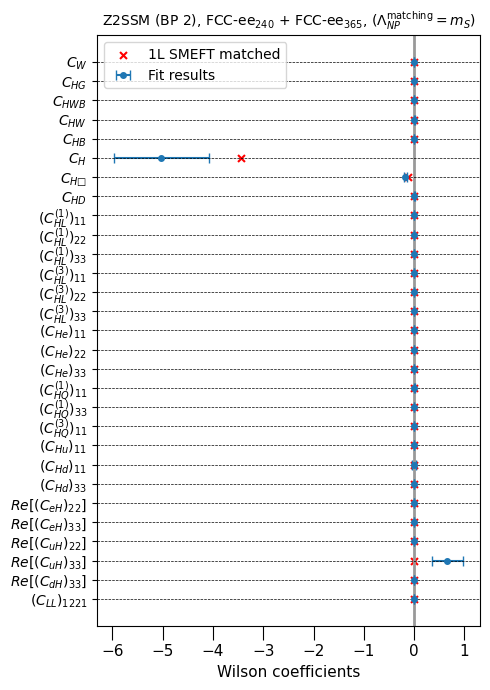

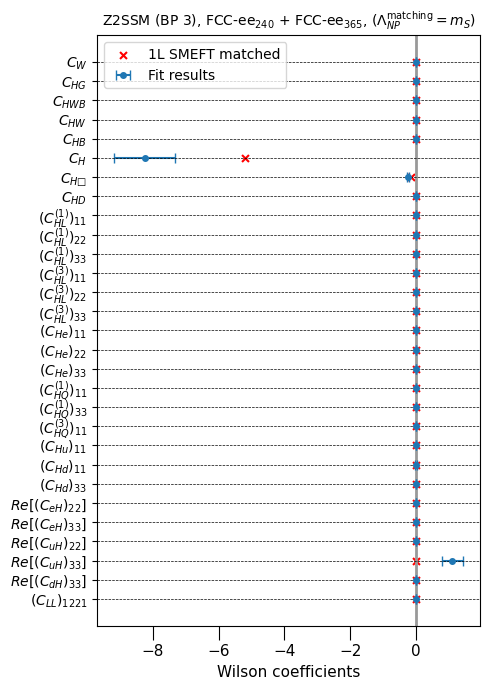

In [136]:
plot_titles = { 
    BP : {
        scenario : rf"{model} ({BP_name}), {scenario_title}, "+r'($\Lambda_{NP}^\mathrm{matching}=$'rf'${lamNP_tex}$)'
        for scenario, scenario_title in zip(all_scenarios, scenario_titles)
    } 
    for BP, BP_name in zip(BPs, BP_names)
}

print(matched_WCs)
lamNP_hepfit = 1000 #GeV
plotted_BPs = [0, 1, 2, 4]  # Indices of BPs to be plotted

matched_WCs_hepfit_compare = {wc : matched_WCs[wc][plotted_BPs] * (lamNP_hepfit)**2 for wc in matched_WCs.keys()}
print(matched_WCs_hepfit_compare)

pullplots.generate_pull_plots_pars(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles,
    model=model,
    colors=None,
    show_plots=True,
    nvar_per_plot=50,
    figsize=(5, 7),
    normalize_pulls=False,
    true_values={
        'values': matched_WCs_hepfit_compare, 
        'label': '1L SMEFT matched', 
        'style': {'s': 25, 'marker': 'x', 'color': 'red'},
        'subtract_true_values': False
    },
    file_suffix=f"_absolute_WCs_lambda_matching_{lamNP_str}",
)


Finding configuration files for the observables

Setting configuration files for scenario: Z2SSM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Full fit flag: use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Files considered:
- Globalfits/AllOps/d6Ops_corr.conf

Reading configuration files for observables
Reading configuration file ./BPBnew_0/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BPBnew_1/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BPBnew_2/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BPBnew_4/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



{'BPBnew_0': {'Z2SSM_FCCee240_FCCee365': {'fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all

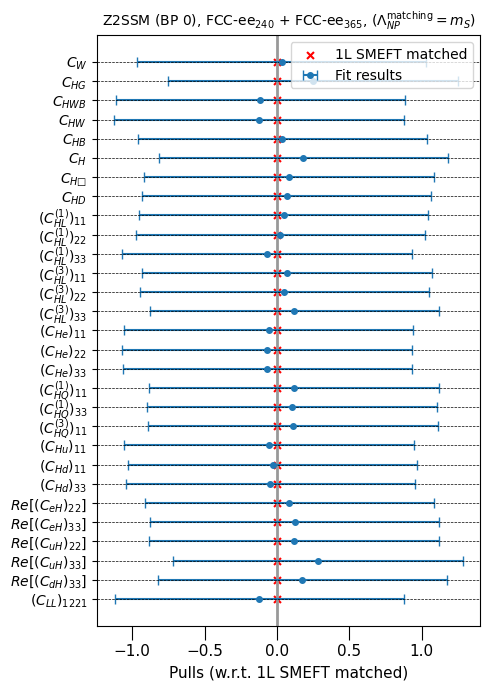

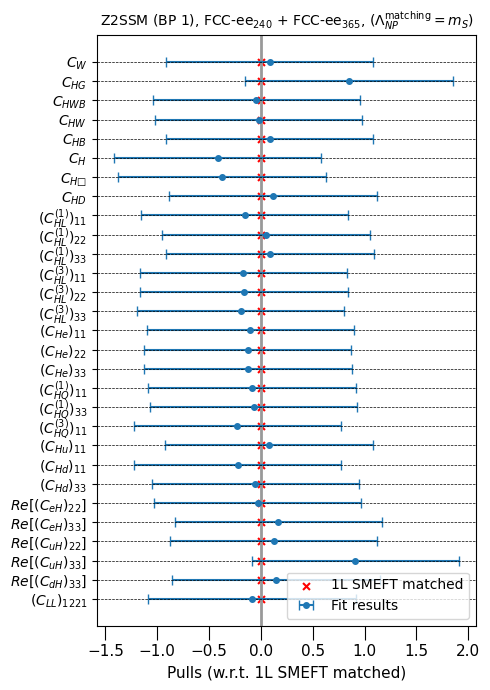

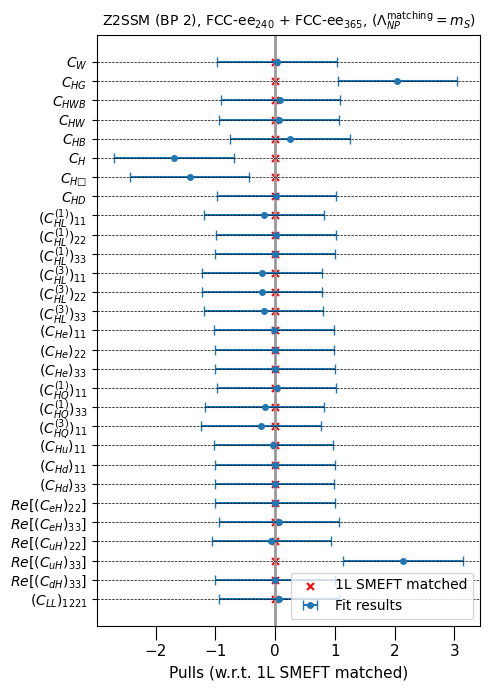

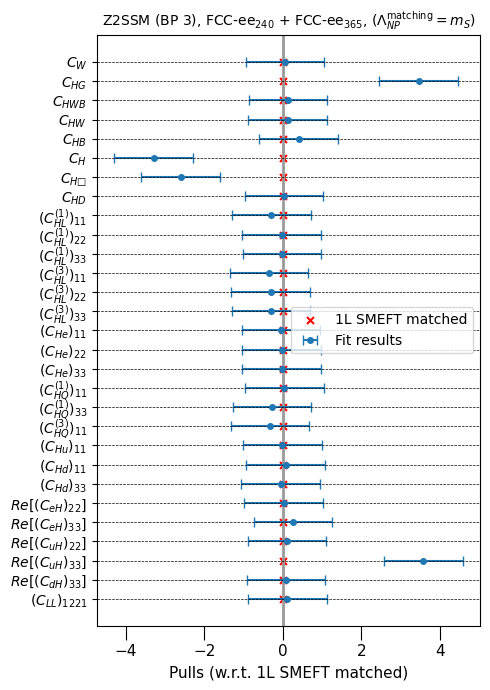

In [137]:

pullplots.generate_pull_plots_pars(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles,
    model=model,
    colors=None,
    show_plots=True,
    nvar_per_plot=50,
    figsize=(5, 7),
    normalize_pulls=True,
    true_values={
        'values': matched_WCs_hepfit_compare, 
        'label': '1L SMEFT matched', 
        'style': {'s': 25, 'marker': 'x', 'color': 'red'},
        'subtract_true_values': True
    },
    file_suffix=f"_WC_pulls_wrt_matched_absolute_WCs_lambda_matching_{lamNP_str}",
)

In [138]:
CH    = matched_WCs["CH"]    [plotted_BPs]
CHbox = matched_WCs["CHbox"] [plotted_BPs]

CH at mS matching: [-0.24413125 -1.72370676 -3.4397087  -5.20772166]

Reading fit results
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_4/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt


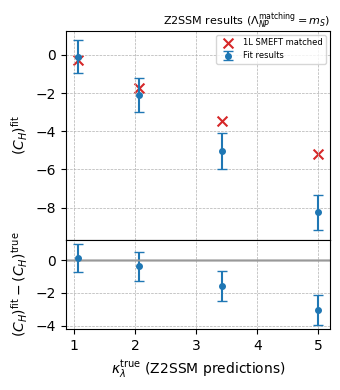


Reading fit results
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_4/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt


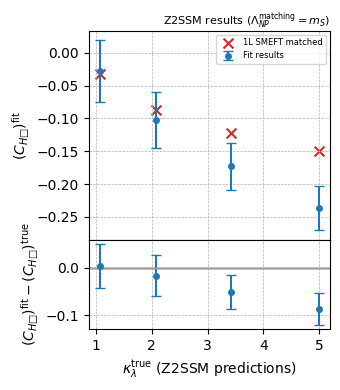

In [139]:
colors = ["tab:blue",]
print("CH at mS matching:", CH*lamNP_hepfit**2)


utils.generate_obs_comparison_plot(
    observable='CH_corr',
    observable_label=r'(C_{H})',
    observable_text='CH',
    true_obs_values=CH*lamNP_hepfit**2,
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dir_compare,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
    model=model,
    plot_labels=spec_labels,
    plot_titles=None,
    group_model_specs=True,
    colors=colors,
    plot_true_obs={"color": "tab:red", "s": 50, "label": "1L SMEFT matched"},
    # plot_true_obs=None,
    show_plots=True,
    # x_lim = (0.5, 5.0),
    # y_lim_ax1=(0.2, 2.2),
    # y_lim_ax2=(-0.7, 0.7),
    leg_fontsize=6,
    spec_distance=0.2,
    # # upper_right_text=r"IDM inputs: strictly 1L BSM contributions",
    # upper_right_text=r"IDM inputs: 1L BSM + $\kappa_\lambda$-dependent diagrams",
    upper_right_text=rf"{model} results "+r'($\Lambda_{{NP}}^{{\mathrm{{matching}}}}=$'rf'${lamNP_tex}$)',
    file_suffix=f"_lambda_matching_{lamNP_str}",
)


utils.generate_obs_comparison_plot(
    observable='CHbox_corr',
    observable_label='(C_{H\u25A1})',
    observable_text='CHbox',
    true_obs_values=CHbox*lamNP_hepfit**2,
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dir_compare,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
    model=model,
    plot_labels=spec_labels,
    plot_titles=None,
    group_model_specs=True,
    colors=colors,
    plot_true_obs={"color": "tab:red", "s": 50, "label": "1L SMEFT matched"},
    # plot_true_obs=None,
    show_plots=True,
    # x_lim = (0.5, 5.0),
    # y_lim_ax1=(0.2, 2.2),
    # y_lim_ax2=(-5, 110),
    leg_fontsize=6,
    spec_distance=0.2,
    # # upper_right_text=r"IDM inputs: strictly 1L BSM contributions",
    # upper_right_text=r"IDM inputs: 1L BSM + $\kappa_\lambda$-dependent diagrams",
    upper_right_text=rf"{model} results "+r'($\Lambda_{{NP}}^{{\mathrm{{matching}}}}=$'rf'${lamNP_tex}$)',
    file_suffix=f"_lambda_matching_{lamNP_str}",
)

### Higgs potential

[[<matplotlib.lines.Line2D object at 0x1543692f2190>, Text(0.5, 0.7, '$\\kappa_\\lambda=1$\n$C_H\\cdot\\frac{\\nu^2}{\\Lambda_{NP}^2}=-5.86e-06$'), <matplotlib.lines.Line2D object at 0x1543692f27f0>, <matplotlib.lines.Line2D object at 0x154369609790>, <matplotlib.lines.Line2D object at 0x1543696099d0>], [<matplotlib.lines.Line2D object at 0x154369609ee0>, Text(0.5, 0.7, '$\\kappa_\\lambda=1.11$\n$C_H\\cdot\\frac{\\nu^2}{\\Lambda_{NP}^2}=-0.0148$'), <matplotlib.lines.Line2D object at 0x154369609bb0>, <matplotlib.lines.Line2D object at 0x1543691c7bb0>, <matplotlib.lines.Line2D object at 0x154369f4d5b0>], [<matplotlib.lines.Line2D object at 0x154369325250>, Text(0.5, 0.7, '$\\kappa_\\lambda=1.79$\n$C_H\\cdot\\frac{\\nu^2}{\\Lambda_{NP}^2}=-0.104$'), <matplotlib.lines.Line2D object at 0x154369325f70>, <matplotlib.lines.Line2D object at 0x154369325e20>, <matplotlib.lines.Line2D object at 0x1543693258b0>], [<matplotlib.lines.Line2D object at 0x154369446d00>, Text(0.5, 0.7, '$\\kappa_\\lambda

MovieWriter ffmpeg unavailable; using Pillow instead.


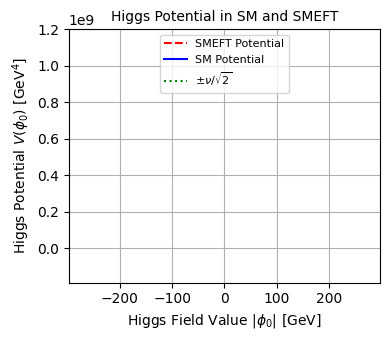

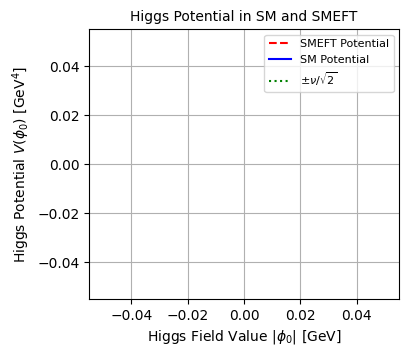

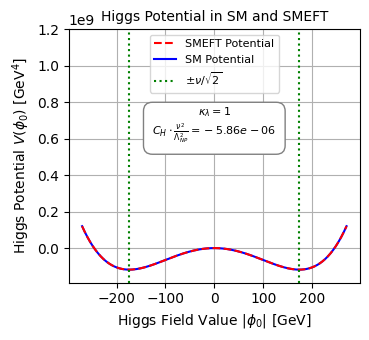

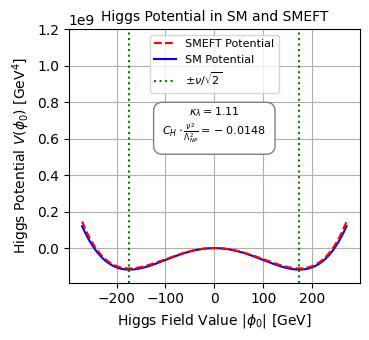

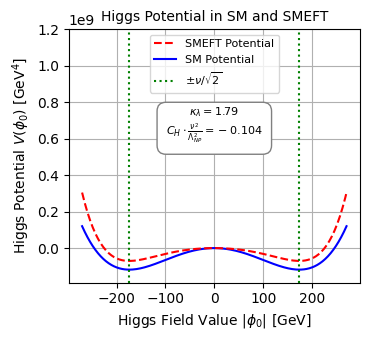

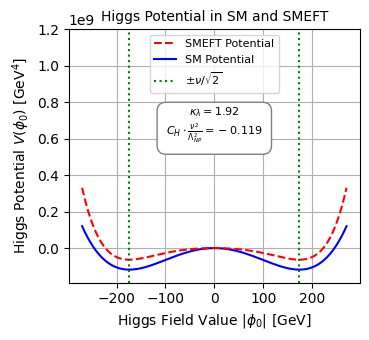

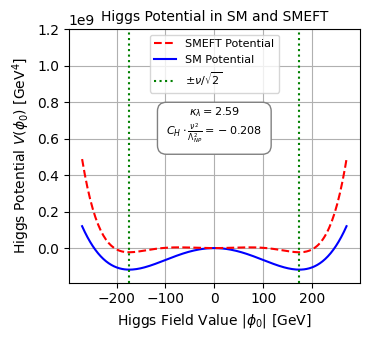

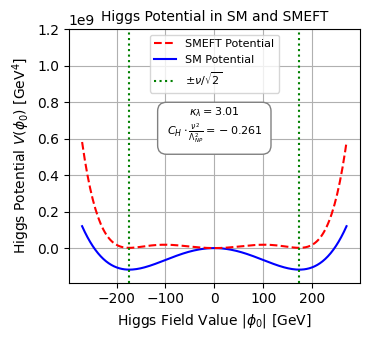

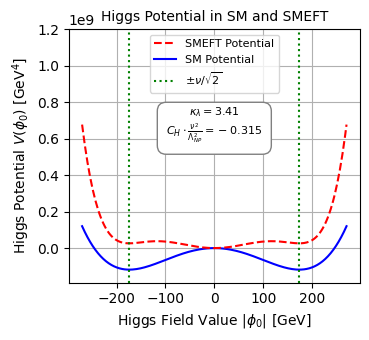

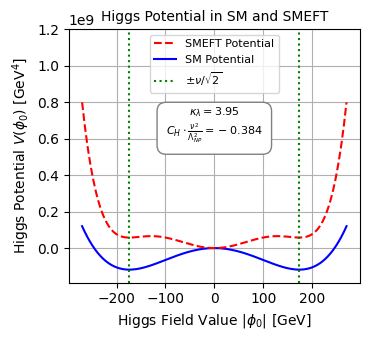

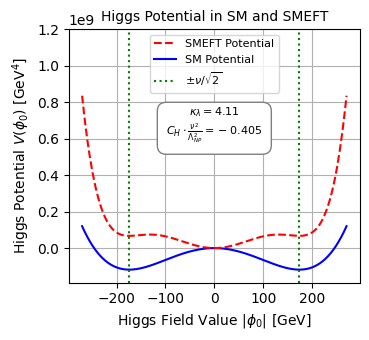

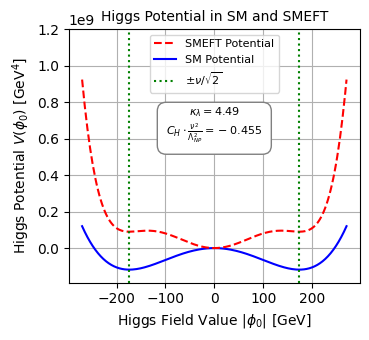

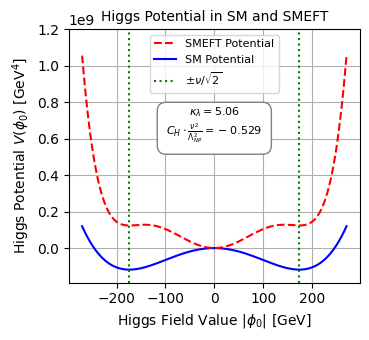

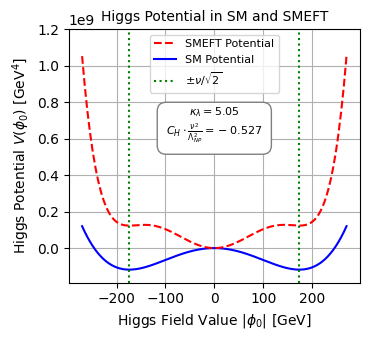

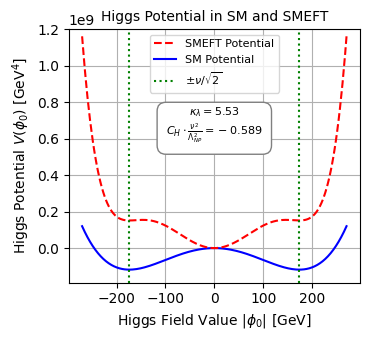

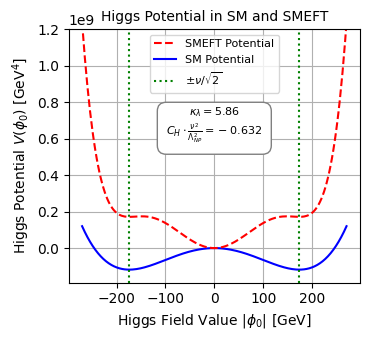

In [140]:
muS_test = muS[:]
lamS_test = lamS[:]
lamSH_test = lamSH[:]
mS_test = mS[:]
Z2SSM = EFT_matching.Z2SSM(muS=muS_test, lamS=lamS_test, lamSH=lamSH_test)
fig, ax, ani, frames = Z2SSM.plot_higgs_potential_SMEFT(lamNP_match=mS_test, animation=True, plot_dir=plot_dir, y_range=(-0.19e9, 1.2e9))
ani.save(f"{plot_dir}/Higgs_potential_SMEFT_matching_example.gif")
# fig.savefig(f"{plot_dir}/Higgs_potential_SMEFT_matching_example.pdf")

HTML(f'<div style="width:600px; height:600px;">{ani.to_jshtml()}</div>')
# fig.show()